<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/006_TensorCudaGPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

#checking available devices
tf.config.experimental.list_physical_devices()
#Checking cuda support for TF
tf.test.is_built_with_cuda()

True

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


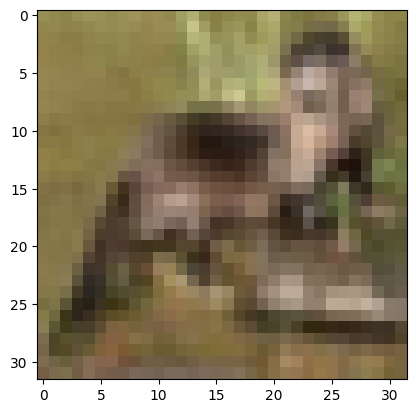

In [2]:
# Load CIFAR-100 dataset
(train_images, train_labels), (test_images, test_labels) = cifar100.load_data()

# Checking dataset shape and visualizing images
train_images.shape, test_images.shape
# Lets visualize one sample image
plt.imshow(train_images[100])

In [3]:
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# One-hot encode the labels
train_labels = to_categorical(train_labels, 100)
test_labels = to_categorical(test_labels, 100)

In [4]:
def getmodel():

    # Define the model
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(32, 32, 3)))  # Flatten the input images
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(100, activation='softmax'))  # 100 classes for CIFAR-100

    # Compile the model
    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return model

In [5]:
%%timeit -n1 -r1
# CPU
with tf.device('/CPU:0'):
    cmodel = getmodel()
    cmodel.fit(train_images, train_labels, epochs = 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.0581 - loss: 4.2809
Epoch 2/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.1348 - loss: 3.6948
Epoch 3/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.1634 - loss: 3.5113
Epoch 4/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.1840 - loss: 3.4049
1min 51s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [6]:
%%timeit -n1 -r1
# CPU
with tf.device('/GPU:0'):
    gmodel = getmodel()
    gmodel.fit(train_images, train_labels, epochs = 4)

Epoch 1/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0481 - loss: 4.3142
Epoch 2/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1299 - loss: 3.7081
Epoch 3/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1632 - loss: 3.5313
Epoch 4/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1825 - loss: 3.4179
21.6 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
